In [1]:
import sys
sys.version

'3.12.0 | packaged by Anaconda, Inc. | (main, Oct  2 2023, 17:20:38) [MSC v.1916 64 bit (AMD64)]'

# Step 2: data collection

In [2]:
import pandas as pd 
df = pd.read_csv(r"data/raw/Cars24_Used_Cars_Raw_Data.csv")
df

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
0,Tata,Zest XE PETROL,2015,Hyderabad,"55,160 km",₹2.59 lakh,"EMI ₹6,824/m*",Petrol,Manual
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,"84,719 km",₹8.46L₹5.05 lakh,"EMI ₹8,915/m*",Petrol,Auto
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,"34,483 km",₹4.03L₹3.04 lakh,"EMI ₹6,762/m*",Petrol,Manual
3,Tata,Nano TWIST XTA,2015,Hyderabad,"46,327 km",₹1.51 lakh,"EMI ₹3,982/m*",Petrol,Auto
4,Tata,Tiago XE DIESEL,2016,Hyderabad,"98,516 km",₹2.71L₹2.60 lakh,"EMI ₹6,847/m*",Diesel,Manual
...,...,...,...,...,...,...,...,...,...
3147,Volkswagen,Vento COMFORTLINE 1.,2011,Coimbatore,"695,604 km",₹1.09 lakh,Not available on EMI,Petrol,Manual
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,"55,404 km",₹2.39 lakh,Not available on EMI,Diesel,Manual
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,"53,441 km",₹9.33 lakh,"EMI ₹15,975/m*",Petrol,Auto
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,"94,479 km",₹3.66 lakh,"EMI ₹9,630/m*",Petrol,Manual


## Data Understanding 

#### Data Types

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3152 entries, 0 to 3151
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Brand       3152 non-null   str  
 1   Variant     3152 non-null   str  
 2   Model Year  3152 non-null   int64
 3   City        3152 non-null   str  
 4   Kilometer   3152 non-null   str  
 5   Price       3152 non-null   str  
 6   EMI         3152 non-null   str  
 7   Fuel_Type   3139 non-null   str  
 8   Drive_Mode  3152 non-null   str  
dtypes: int64(1), str(8)
memory usage: 221.8 KB


# Step 3 : EDA

#### missing values check 

In [4]:
df.isna().sum()

Brand          0
Variant        0
Model Year     0
City           0
Kilometer      0
Price          0
EMI            0
Fuel_Type     13
Drive_Mode     0
dtype: int64

### Duplicates records 

In [5]:
df.duplicated().sum()

np.int64(0)

## Stats Features 

In [6]:
df.describe()

,Model Year
count,3152.000000
mean,2018.112627
std,3.528234
min,2008.000000
25%,2016.000000
50%,2018.000000
75%,2021.000000
max,2025.000000


In [8]:
df.describe(include="all")

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
count,3152,3152,3152.000000,3152,3152,3152,3152,3139,3152
unique,11,1007,NaN,15,2875,2350,2040,4,2
top,Maruti,Ecosport TITANIUM 1.5L DIESEL,NaN,New-delhi,"00,000 km",₹5.10 lakh,Not available on EMI,Petrol,Manual
freq,340,46,NaN,406,4,8,206,2134,2349
mean,NaN,NaN,2018.112627,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,3.528234,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,2008.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2016.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN


## value counts of key categorical features 

In [9]:
df["Brand"].value_counts()

Brand
Maruti        340
Tata          338
Hyundai       331
Honda         327
Mahindra      306
Renault       300
Ford          293
KIA           280
Toyota        274
Volkswagen    257
BMW           106
Name: count, dtype: int64

In [10]:
df["City"].value_counts()

City
New-delhi     406
Noida         401
Hyderabad     219
Mumbai        214
Bangalore     209
Pune          208
Ahmedabad     207
Chennai       199
Kolkata       187
Lucknow       185
Jaipur        176
Agra          159
Surat         152
Kochi         137
Coimbatore     93
Name: count, dtype: int64

In [11]:
df["Fuel_Type"].value_counts()

Fuel_Type
Petrol      2134
Diesel       877
CNG          122
Electric       6
Name: count, dtype: int64

In [12]:
df["Drive_Mode"].value_counts()

Drive_Mode
Manual    2349
Auto       803
Name: count, dtype: int64

In [21]:
df.columns

Index(['Brand', 'Variant', 'Model Year', 'City', 'Kilometer', 'Price', 'EMI',
       'Fuel_Type', 'Drive_Mode'],
      dtype='str')

## Varaints 

In [22]:
df["Variant"]

0                        Zest XE PETROL
1       NEXON XZA PLUS PETROL DUAL TONE
2                   TIGOR XZ (O) PETROL
3                        Nano TWIST XTA
4                       Tiago XE DIESEL
                     ...               
3147               Vento COMFORTLINE 1.
3148           Vento HIGHLINE DIESEL 1.
3149                 Polo 1.0 GT TSI AT
3150                  Polo HIGHLINE1.2L
3151           Vento HIGHLINE PETROL AT
Name: Variant, Length: 3139, dtype: str

### 'Kilometer'

In [28]:
df['Kilometer'] = df['Kilometer'].str.replace(" km", "").str.replace(",","").astype(int)

In [29]:
min(df['Kilometer']), max(df['Kilometer'])

(0, 990803)

In [31]:
import matplotlib.pyplot as plt 
import seaborn as sns 

<Axes: ylabel='Frequency'>

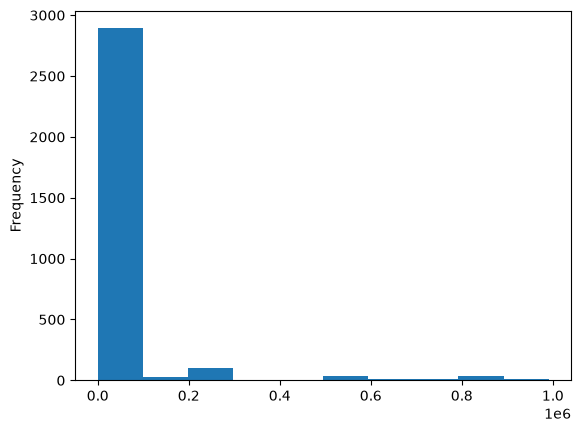

In [33]:
df['Kilometer'].plot(kind="hist")

<Axes: ylabel='Density'>

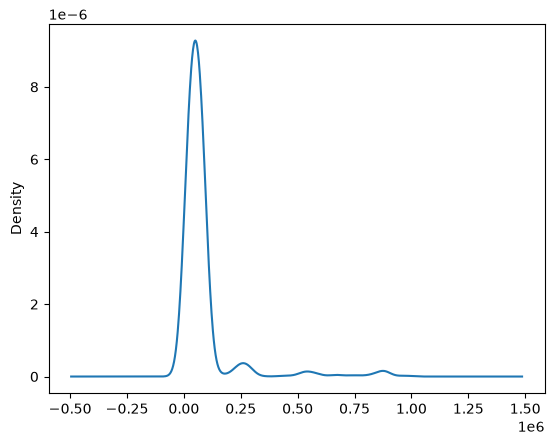

In [35]:
df['Kilometer'].plot(kind="kde")

C:\Users\shrid\AppData\Local\Temp\ipykernel_34616\2064738825.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Kilometer"])


<Axes: xlabel='Kilometer', ylabel='Density'>

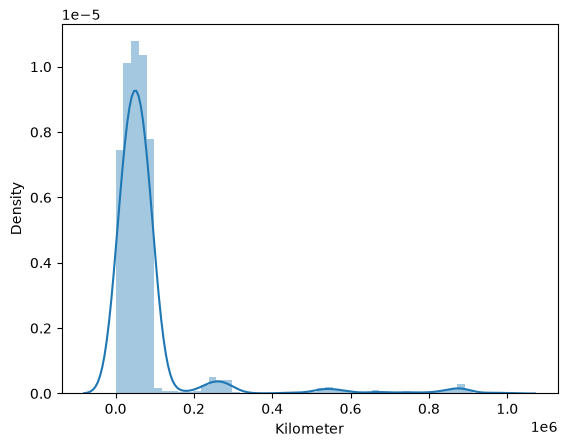

In [36]:
sns.distplot(df["Kilometer"])

<Axes: >

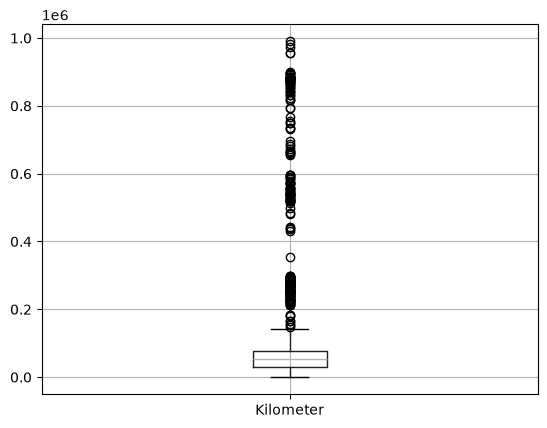

In [38]:
df[["Kilometer"]].boxplot()

In [40]:
df["Kilometer"].quantile(0.75)

np.float64(77151.0)

In [41]:
IQR = df["Kilometer"].quantile(0.75) - df["Kilometer"].quantile(0.25)
IQR

np.float64(46620.0)

In [43]:
upper_tail = df["Kilometer"].quantile(0.75)  + (1.5 * IQR) 
upper_tail

np.float64(147081.0)

In [44]:
df["Kilometer"].quantile(0.90)

np.float64(95700.6)

In [45]:
df["Kilometer"].quantile(0.95)

np.float64(269012.8)

In [46]:
df["Kilometer"].quantile(0.99)

np.float64(866555.2799999999)

In [47]:
df[df["Kilometer"] <= 600000]

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,₹2.59 lakh,"EMI ₹6,824/m*",Petrol,Manual
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,₹8.46L₹5.05 lakh,"EMI ₹8,915/m*",Petrol,Auto
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,₹4.03L₹3.04 lakh,"EMI ₹6,762/m*",Petrol,Manual
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,₹1.51 lakh,"EMI ₹3,982/m*",Petrol,Auto
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,₹2.71L₹2.60 lakh,"EMI ₹6,847/m*",Diesel,Manual
...,...,...,...,...,...,...,...,...,...
3146,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,₹10.94 lakh,"EMI ₹18,730/m*",Petrol,Auto
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,₹2.39 lakh,Not available on EMI,Diesel,Manual
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,₹9.33 lakh,"EMI ₹15,975/m*",Petrol,Auto
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,₹3.66 lakh,"EMI ₹9,630/m*",Petrol,Manual


In [48]:
df.shape

(3139, 9)

In [49]:
3139 - 3073

66

In [50]:
df[df["Kilometer"] <= 500000]

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,₹2.59 lakh,"EMI ₹6,824/m*",Petrol,Manual
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,₹8.46L₹5.05 lakh,"EMI ₹8,915/m*",Petrol,Auto
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,₹4.03L₹3.04 lakh,"EMI ₹6,762/m*",Petrol,Manual
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,₹1.51 lakh,"EMI ₹3,982/m*",Petrol,Auto
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,₹2.71L₹2.60 lakh,"EMI ₹6,847/m*",Diesel,Manual
...,...,...,...,...,...,...,...,...,...
3146,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,₹10.94 lakh,"EMI ₹18,730/m*",Petrol,Auto
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,₹2.39 lakh,Not available on EMI,Diesel,Manual
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,₹9.33 lakh,"EMI ₹15,975/m*",Petrol,Auto
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,₹3.66 lakh,"EMI ₹9,630/m*",Petrol,Manual


In [51]:
3139 - 3032

107

In [52]:
 df1 = df[df["Kilometer"] <= 500000]

<Axes: >

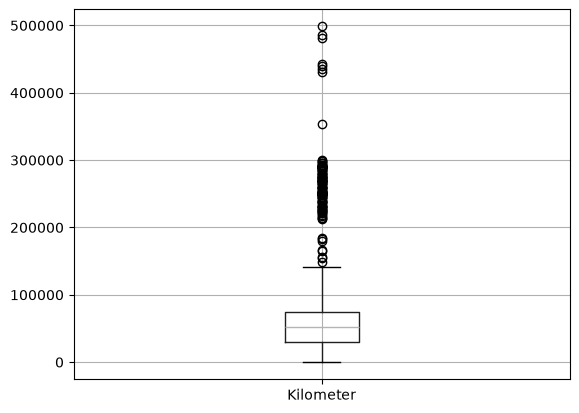

In [54]:
df1[["Kilometer"]].boxplot()

### observations 

In [ ]:
1. it contains lot of outliers
2. 90th percentile value is 95700 and rest 90th to 10th percentile values are huge. 
3. upper_tail from outlier also crossing this observations 
#### Conclusion 
as 95th perctile value is around 250000 so filtering the samples belwo 500000 


In [56]:
 df = df[df["Kilometer"] <= 500000]

In [58]:
df.columns

Index(['Brand', 'Variant', 'Model Year', 'City', 'Kilometer', 'Price', 'EMI',
       'Fuel_Type', 'Drive_Mode'],
      dtype='str')

## Price 

In [59]:
df["Price"].head()

0          ₹2.59 lakh
1    ₹8.46L₹5.05 lakh
2    ₹4.03L₹3.04 lakh
3          ₹1.51 lakh
4    ₹2.71L₹2.60 lakh
Name: Price, dtype: str

In [ ]:
### observation 
1. it contains rupee symbol and lakhs as trailing text 
2. some samples contains two values 


In [ ]:
## after meeting those samples contain two values meaning one value is actual value and second discounted value. 
## we are going to use discounted price which is last one. 

# Step 4: Feature engineering 

### handling missing values 

In [13]:
df.isna().sum()

Brand          0
Variant        0
Model Year     0
City           0
Kilometer      0
Price          0
EMI            0
Fuel_Type     13
Drive_Mode     0
dtype: int64

In [14]:
df[df["Fuel_Type"].isnull()]

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
568,Toyota,Camry HYBRID,2021,Mumbai,"39,751 km",₹30.75L₹28.90 lakh,"EMI ₹49,484/m*",NaN,Auto
782,Toyota,URBAN CRUISER HYRYDER V HYBRID,2023,Pune,"60,430 km",₹17.00 lakh,"EMI ₹29,108/m*",NaN,Auto
783,Toyota,Camry HYBRID,2016,Pune,"23,698 km",₹13.60 lakh,"EMI ₹29,570/m*",NaN,Auto
1298,Toyota,Camry HYBRID,2024,New-delhi,"5,399 km",₹39.50L₹38.00 lakh,"EMI ₹65,065/m*",NaN,Auto
1299,Toyota,Camry HYBRID,2023,New-delhi,"15,756 km",₹34.90L₹34.00 lakh,"EMI ₹58,216/m*",NaN,Auto
1317,Toyota,Camry HYBRID,2016,New-delhi,"67,776 km",₹9.62 lakh,"EMI ₹20,918/m*",NaN,Auto
1568,Toyota,Camry HYBRID,2018,Surat,"74,333 km",₹11.85L₹11.00 lakh,"EMI ₹18,835/m*",NaN,Auto
2602,Toyota,Camry HYBRID,2017,Kolkata,"42,258 km",₹11.71L₹11.20 lakh,"EMI ₹21,318/m*",NaN,Auto
2604,Toyota,URBAN CRUISER HYRYDER V HYBRID,2022,Kolkata,"35,948 km",₹13.75 lakh,"EMI ₹23,543/m*",NaN,Auto
2605,Toyota,INNOVA HYCROSS ZX HYBRID 7 STR,2023,Kolkata,"63,922 km",₹21.35 lakh,"EMI ₹36,556/m*",NaN,Auto


In [18]:
df.isna().sum() / df.shape[0] * 100

Brand         0.000000
Variant       0.000000
Model Year    0.000000
City          0.000000
Kilometer     0.000000
Price         0.000000
EMI           0.000000
Fuel_Type     0.412437
Drive_Mode    0.000000
dtype: float64

#### observation 

In [ ]:
1. All missing value were observed in toyota brand 
2. overall 0.41% values are missing which is small compared to total dataset
### conclusion 
3. rows/samples removed to maintain dataset original integrity. 

In [19]:
df = df.dropna(subset=["Fuel_Type"])

In [20]:
df.shape

(3139, 9)

# cleaning price columns 

In [62]:
df["Price"]

0             ₹2.59 lakh
1       ₹8.46L₹5.05 lakh
2       ₹4.03L₹3.04 lakh
3             ₹1.51 lakh
4       ₹2.71L₹2.60 lakh
              ...       
3146         ₹10.94 lakh
3148          ₹2.39 lakh
3149          ₹9.33 lakh
3150          ₹3.66 lakh
3151    ₹5.18L₹4.01 lakh
Name: Price, Length: 3032, dtype: str

In [69]:
price_value = df["Price"].str.findall(r"\d+\.?\d*")
price_value

0             [2.59]
1       [8.46, 5.05]
2       [4.03, 3.04]
3             [1.51]
4       [2.71, 2.60]
            ...     
3146         [10.94]
3148          [2.39]
3149          [9.33]
3150          [3.66]
3151    [5.18, 4.01]
Name: Price, Length: 3032, dtype: object

In [78]:
float(price_value[0][-1]) * 100000

259000.0

In [79]:
df["Final_Price"] = price_value.apply(
    lambda x: float(x[-1]) * 100000
)

In [80]:
df["Final_Price"]

0        259000.0
1        505000.0
2        304000.0
3        151000.0
4        260000.0
          ...    
3146    1094000.0
3148     239000.0
3149     933000.0
3150     366000.0
3151     401000.0
Name: Final_Price, Length: 3032, dtype: float64

In [81]:
df

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode,Final_Price
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,₹2.59 lakh,"EMI ₹6,824/m*",Petrol,Manual,259000.0
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,₹8.46L₹5.05 lakh,"EMI ₹8,915/m*",Petrol,Auto,505000.0
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,₹4.03L₹3.04 lakh,"EMI ₹6,762/m*",Petrol,Manual,304000.0
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,₹1.51 lakh,"EMI ₹3,982/m*",Petrol,Auto,151000.0
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,₹2.71L₹2.60 lakh,"EMI ₹6,847/m*",Diesel,Manual,260000.0
...,...,...,...,...,...,...,...,...,...,...
3146,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,₹10.94 lakh,"EMI ₹18,730/m*",Petrol,Auto,1094000.0
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,₹2.39 lakh,Not available on EMI,Diesel,Manual,239000.0
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,₹9.33 lakh,"EMI ₹15,975/m*",Petrol,Auto,933000.0
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,₹3.66 lakh,"EMI ₹9,630/m*",Petrol,Manual,366000.0


In [82]:
df["Final_Price"].isna().sum()

np.int64(0)

In [83]:
df["Final_Price"].info()

<class 'pandas.Series'>
Index: 3032 entries, 0 to 3151
Series name: Final_Price
Non-Null Count  Dtype  
--------------  -----  
3032 non-null   float64
dtypes: float64(1)
memory usage: 111.9 KB


In [84]:
df["Final_Price"].describe()

count    3.032000e+03
mean     5.816758e+05
std      5.413602e+05
min      5.900000e+04
25%      2.910000e+05
50%      4.430000e+05
75%      6.880000e+05
max      8.500000e+06
Name: Final_Price, dtype: float64

<Axes: >

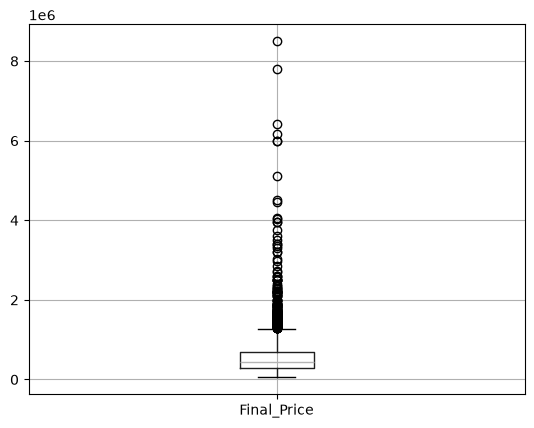

In [85]:
df[["Final_Price"]].boxplot()

In [ ]:
## droping raw price columns 

In [87]:
df.drop("Price", axis=1, inplace=True)

In [88]:
df

,Brand,Variant,Model Year,City,Kilometer,EMI,Fuel_Type,Drive_Mode,Final_Price
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,"EMI ₹6,824/m*",Petrol,Manual,259000.0
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,"EMI ₹8,915/m*",Petrol,Auto,505000.0
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,"EMI ₹6,762/m*",Petrol,Manual,304000.0
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,"EMI ₹3,982/m*",Petrol,Auto,151000.0
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,"EMI ₹6,847/m*",Diesel,Manual,260000.0
...,...,...,...,...,...,...,...,...,...
3146,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,"EMI ₹18,730/m*",Petrol,Auto,1094000.0
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,Not available on EMI,Diesel,Manual,239000.0
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,"EMI ₹15,975/m*",Petrol,Auto,933000.0
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,"EMI ₹9,630/m*",Petrol,Manual,366000.0


# EMI

In [89]:
df["EMI"]

0              EMI ₹6,824/m*
1              EMI ₹8,915/m*
2              EMI ₹6,762/m*
3              EMI ₹3,982/m*
4              EMI ₹6,847/m*
                ...         
3146          EMI ₹18,730/m*
3148    Not available on EMI
3149          EMI ₹15,975/m*
3150           EMI ₹9,630/m*
3151           EMI ₹8,920/m*
Name: EMI, Length: 3032, dtype: str

In [91]:
df["EMI"] = df["EMI"].str.extract(r"₹([\d,]+)")

In [92]:
df["EMI"]

0        6,824
1        8,915
2        6,762
3        3,982
4        6,847
         ...  
3146    18,730
3148       NaN
3149    15,975
3150     9,630
3151     8,920
Name: EMI, Length: 3032, dtype: str

In [94]:
df["EMI"] = df["EMI"].str.replace(",","")
df["EMI"]

0        6824
1        8915
2        6762
3        3982
4        6847
        ...  
3146    18730
3148      NaN
3149    15975
3150     9630
3151     8920
Name: EMI, Length: 3032, dtype: str

In [97]:
df["EMI"] = df["EMI"].astype(float)

In [99]:
df["EMI"]

0        6824.0
1        8915.0
2        6762.0
3        3982.0
4        6847.0
         ...   
3146    18730.0
3148        NaN
3149    15975.0
3150     9630.0
3151     8920.0
Name: EMI, Length: 3032, dtype: float64

In [100]:
df.info()

<class 'pandas.DataFrame'>
Index: 3032 entries, 0 to 3151
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Brand        3032 non-null   str    
 1   Variant      3032 non-null   str    
 2   Model Year   3032 non-null   int64  
 3   City         3032 non-null   str    
 4   Kilometer    3032 non-null   int64  
 5   EMI          2832 non-null   float64
 6   Fuel_Type    3032 non-null   str    
 7   Drive_Mode   3032 non-null   str    
 8   Final_Price  3032 non-null   float64
dtypes: float64(2), int64(2), str(5)
memory usage: 301.4 KB


##  Fuel_Type

In [102]:
df["Fuel_Type"].value_counts()

Fuel_Type
Petrol      2073
Diesel       834
CNG          121
Electric       4
Name: count, dtype: int64

In [103]:
df["Fuel_Type"].isna().sum()

np.int64(0)

## Drive_Mode   

In [104]:
df["Drive_Mode"].value_counts()

Drive_Mode
Manual    2244
Auto       788
Name: count, dtype: int64

### Client meeting 

In [ ]:
# car age 
# km_per_year 
# price_segment 
# age_bucket

In [105]:
df

,Brand,Variant,Model Year,City,Kilometer,EMI,Fuel_Type,Drive_Mode,Final_Price
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,6824.0,Petrol,Manual,259000.0
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,8915.0,Petrol,Auto,505000.0
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,6762.0,Petrol,Manual,304000.0
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,3982.0,Petrol,Auto,151000.0
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,6847.0,Diesel,Manual,260000.0
...,...,...,...,...,...,...,...,...,...
3146,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,18730.0,Petrol,Auto,1094000.0
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,NaN,Diesel,Manual,239000.0
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,15975.0,Petrol,Auto,933000.0
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,9630.0,Petrol,Manual,366000.0


## car_age

In [106]:
CURRENT_YEAR = 2026
df["Car_Age"] = CURRENT_YEAR - df["Model Year"] 

In [108]:
df

,Brand,Variant,Model Year,City,Kilometer,EMI,Fuel_Type,Drive_Mode,Final_Price,Car_Age
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,6824.0,Petrol,Manual,259000.0,11
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,8915.0,Petrol,Auto,505000.0,7
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,6762.0,Petrol,Manual,304000.0,9
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,3982.0,Petrol,Auto,151000.0,11
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,6847.0,Diesel,Manual,260000.0,10
...,...,...,...,...,...,...,...,...,...,...
3146,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,18730.0,Petrol,Auto,1094000.0,4
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,NaN,Diesel,Manual,239000.0,15
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,15975.0,Petrol,Auto,933000.0,5
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,9630.0,Petrol,Manual,366000.0,11


## km_per_year 

In [111]:
df["km_per_year"] = round(df["Kilometer"] / df["Car_Age"],1)
df["km_per_year"]

0        5014.5
1       12102.7
2        3831.4
3        4211.5
4        9851.6
         ...   
3146    22243.5
3148     3693.6
3149    10688.2
3150     8589.0
3151     2116.5
Name: km_per_year, Length: 3032, dtype: float64

## # price_segment 

In [ ]:
vehicles are categorized into price ranges: 
budegt - upto 5L
mid - 5-10 
upper-mid - 10-20 
premium - 20L


In [112]:
max(df["Final_Price"])

8500000.0

In [117]:
bins = [0,500000,1000000,2000000,10000000]
labels = ["Budget","Mid","Upper-Mid","Premium"]
df["Price_Segment"] = pd.cut(df["Final_Price"], bins= bins, labels = labels)

In [118]:
df["Price_Segment"].value_counts()

Price_Segment
Budget       1763
Mid           916
Upper-Mid     295
Premium        58
Name: count, dtype: int64

In [119]:
df["Price_Segment"].value_counts()/df.shape[0] * 100

Price_Segment
Budget       58.146438
Mid          30.211082
Upper-Mid     9.729551
Premium       1.912929
Name: count, dtype: float64

## age bucket 

In [ ]:
vechiels are grouped into age group 

0-3 year 
4-6 year 
7-10 year 
10+ year 

In [121]:
bins = [0,3,6,10,20]
labels = ["0-3","4-6","7-10","10+"]
df["Age_Bucket"] = pd.cut(df["Car_Age"], bins= bins, labels= labels)

In [122]:
df["Age_Bucket"].value_counts()

Age_Bucket
7-10    1157
4-6      789
10+      738
0-3      348
Name: count, dtype: int64

In [123]:
df

,Brand,Variant,Model Year,City,Kilometer,EMI,Fuel_Type,Drive_Mode,Final_Price,Car_Age,km_per_year,Price_Segment,Age_Bucket
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,6824.0,Petrol,Manual,259000.0,11,5014.5,Budget,10+
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,8915.0,Petrol,Auto,505000.0,7,12102.7,Mid,7-10
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,6762.0,Petrol,Manual,304000.0,9,3831.4,Budget,7-10
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,3982.0,Petrol,Auto,151000.0,11,4211.5,Budget,10+
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,6847.0,Diesel,Manual,260000.0,10,9851.6,Budget,7-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3146,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,18730.0,Petrol,Auto,1094000.0,4,22243.5,Upper-Mid,4-6
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,NaN,Diesel,Manual,239000.0,15,3693.6,Budget,10+
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,15975.0,Petrol,Auto,933000.0,5,10688.2,Mid,4-6
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,9630.0,Petrol,Manual,366000.0,11,8589.0,Budget,10+


# final clean dataset 

In [124]:
df.to_csv(r"data/clean/car_clean.csv")

# Step 5: Fetaure Selection